# Tugas Praktikum! Ke-10
*Dosen Pengampu:* Adinda Putri S.Tr.Kom. M.,Kom  


*Nama       :* Yogi Firnanda Saputra  
*NIM        :* 2511102441170  
*Kelas      :* Reguler B  
*Mata Kuliah:* Algoritma dan Struktur Data

Inorder: [20, 30, 40, 50, 60, 70, 80]
K-th smallest (k=3): 40
Rank of 60: 4
LCA(20,40): 30
Range [30,70]: [30, 40, 50, 60, 70]


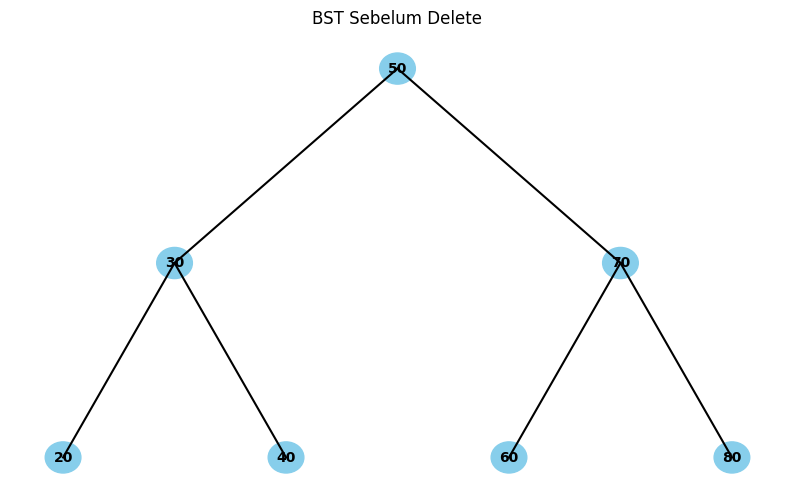

After delete 50: [20, 30, 40, 60, 70, 80]


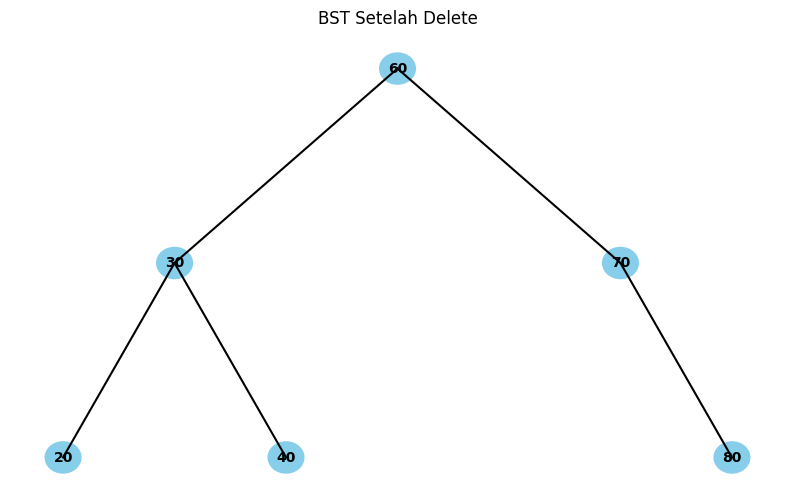

Iterator: 20 30 40 60 70 80 

In [2]:
# =========================
# IMPORT
# =========================
import matplotlib.pyplot as plt


# =========================
# NODE
# =========================
class Node:
    def __init__(self, key):
        self.val = key
        self.left = None
        self.right = None
        self.size = 1


# =========================
# BST
# =========================
class BST:
    def __init__(self):
        self.root = None

    # =========================
    # Utility
    # =========================
    def get_size(self, node):
        return node.size if node else 0

    def update_size(self, node):
        if node:
            node.size = (
                1
                + self.get_size(node.left)
                + self.get_size(node.right)
            )

    # =========================
    # Insert
    # =========================
    def insert(self, node, key):
        if node is None:
            return Node(key)

        if key < node.val:
            node.left = self.insert(node.left, key)
        else:
            node.right = self.insert(node.right, key)

        self.update_size(node)
        return node

    # =========================
    # Delete
    # =========================
    def minValueNode(self, node):
        current = node

        while current.left:
            current = current.left

        return current

    def delete(self, node, key):
        if node is None:
            return node

        if key < node.val:
            node.left = self.delete(node.left, key)

        elif key > node.val:
            node.right = self.delete(node.right, key)

        else:
            # node dengan 1 child / tanpa child
            if node.left is None:
                return node.right

            elif node.right is None:
                return node.left

            # node dengan 2 child
            temp = self.minValueNode(node.right)

            node.val = temp.val

            node.right = self.delete(node.right, temp.val)

        self.update_size(node)
        return node

    # =========================
    # Inorder Traversal
    # =========================
    def inorder(self, node):
        if node is None:
            return []

        return (
            self.inorder(node.left)
            + [node.val]
            + self.inorder(node.right)
        )

    # =========================
    # K-th Smallest
    # =========================
    def kth_smallest(self, node, k):
        if node is None:
            return None

        left_size = self.get_size(node.left)

        if k == left_size + 1:
            return node.val

        elif k <= left_size:
            return self.kth_smallest(node.left, k)

        else:
            return self.kth_smallest(
                node.right,
                k - left_size - 1
            )

    # =========================
    # Rank
    # =========================
    def get_rank(self, node, key):
        if node is None:
            return 0

        if key < node.val:
            return self.get_rank(node.left, key)

        elif key > node.val:
            return (
                1
                + self.get_size(node.left)
                + self.get_rank(node.right, key)
            )

        else:
            return self.get_size(node.left)

    # =========================
    # LCA
    # =========================
    def LCA(self, node, p, q):
        if node is None:
            return None

        if p < node.val and q < node.val:
            return self.LCA(node.left, p, q)

        elif p > node.val and q > node.val:
            return self.LCA(node.right, p, q)

        return node

    # =========================
    # Range Query
    # =========================
    def range_query(self, node, L, R):
        if node is None:
            return []

        result = []

        if L < node.val:
            result += self.range_query(node.left, L, R)

        if L <= node.val <= R:
            result.append(node.val)

        if node.val < R:
            result += self.range_query(node.right, L, R)

        return result


# =========================
# BST Iterator
# =========================
class BSTIterator:
    def __init__(self, root):
        self.stack = []
        self.push_left(root)

    def push_left(self, node):
        while node:
            self.stack.append(node)
            node = node.left

    def next(self):
        node = self.stack.pop()

        self.push_left(node.right)

        return node.val

    def has_next(self):
        return len(self.stack) > 0


# =========================
# VISUALISASI BST
# =========================
class BSTVisualizer:

    def __init__(self):
        self.pos = {}

    def get_positions(self, node, x=0, y=0, dx=1):
        """
        Mengatur posisi node
        """

        if node is None:
            return

        self.pos[node.val] = (x, y)

        # kiri
        self.get_positions(
            node.left,
            x - dx,
            y - 1,
            dx / 2
        )

        # kanan
        self.get_positions(
            node.right,
            x + dx,
            y - 1,
            dx / 2
        )

    def draw_edges(self, node):
        """
        Menggambar garis antar node
        """

        if node is None:
            return

        x, y = self.pos[node.val]

        # garis ke kiri
        if node.left:
            x2, y2 = self.pos[node.left.val]

            plt.plot(
                [x, x2],
                [y, y2],
                color="black"
            )

            self.draw_edges(node.left)

        # garis ke kanan
        if node.right:
            x2, y2 = self.pos[node.right.val]

            plt.plot(
                [x, x2],
                [y, y2],
                color="black"
            )

            self.draw_edges(node.right)

    def draw_nodes(self):
        """
        Menggambar node
        """

        for value, (x, y) in self.pos.items():

            circle = plt.Circle(
                (x, y),
                0.08,
                color="skyblue"
            )

            plt.gca().add_patch(circle)

            plt.text(
                x,
                y,
                str(value),
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold'
            )

    def draw_tree(self, root, title="BST Visualization"):

        self.pos = {}

        self.get_positions(root)

        plt.figure(figsize=(10, 6))

        self.draw_edges(root)

        self.draw_nodes()

        plt.title(title)

        plt.axis("off")

        plt.show()


# =========================
# MAIN PROGRAM
# =========================
if __name__ == "__main__":

    bst = BST()

    data = [50, 30, 20, 40, 70, 60, 80]

    # insert data
    for x in data:
        bst.root = bst.insert(bst.root, x)

    # output
    print("Inorder:", bst.inorder(bst.root))

    print(
        "K-th smallest (k=3):",
        bst.kth_smallest(bst.root, 3)
    )

    print(
        "Rank of 60:",
        bst.get_rank(bst.root, 60)
    )

    lca = bst.LCA(bst.root, 20, 40)

    print(
        "LCA(20,40):",
        lca.val if lca else None
    )

    print(
        "Range [30,70]:",
        bst.range_query(bst.root, 30, 70)
    )

    # =========================
    # VISUALISASI SEBELUM DELETE
    # =========================
    visual = BSTVisualizer()

    visual.draw_tree(
        bst.root,
        "BST Sebelum Delete"
    )

    # =========================
    # DELETE
    # =========================
    bst.root = bst.delete(bst.root, 50)

    print(
        "After delete 50:",
        bst.inorder(bst.root)
    )

    # =========================
    # VISUALISASI SETELAH DELETE
    # =========================
    visual.draw_tree(
        bst.root,
        "BST Setelah Delete"
    )

    # =========================
    # ITERATOR
    # =========================
    print("Iterator:", end=" ")

    it = BSTIterator(bst.root)

    while it.has_next():
        print(it.next(), end=" ")